# Ten kilowatts on a house in Aachen

A domestic photovoltaic system earns money two ways, and they behave quite
differently.  Every kilowatt-hour used in the house avoids the retail price,
which rises.  Every kilowatt-hour exported earns the feed-in tariff, which is
fixed in money of the day for twenty years and therefore falls in real terms.

So the whole appraisal turns on one number nobody actually knows: the share of
output used on site.  This notebook states that share rather than pretending to
simulate it, and then asks the only question worth asking about it — **how low
can it go before the roof stops paying?**

In [1]:
from datetime import date

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

from simplyinvest import Term, Timeline, appraise
from simplyinvest.appraisal import Alternative, Case
from simplyinvest.domain import GeometricDecline
from simplyinvest.financing import CashPurchase
from simplyinvest.pv import (
    GENERATED,
    DeclaredShare,
    Householder,
    Inverter,
    PvOperations,
    PvSupply,
    ResidentialExempt,
    StatedYield,
    StaticPrice,
    System,
)
from simplyinvest.pv.incentives import (
    EEG_2026_AUGUST,
    EEG_2027_DRAFT,
    FeedInTariff,
    FixedTariff,
    blended_rate,
)
from simplyinvest.report import (
    breakdown_chart,
    breakdown_frame,
    cumulative_chart,
    distribution_chart,
    money_formatter,
    ranking_frame,
    sweep_chart,
    tornado_chart,
    tornado_frame,
)
from simplyinvest.uncertain import Normal, Triangular, one_way, simulate, switch_point, tornado, uncertain

SUN = "#b7791f"
GRID = "#2b6cb0"

plt.rcParams.update(
    {
        "figure.figsize": (9.5, 4.5),
        "figure.dpi": 110,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "axes.prop_cycle": plt.cycler(color=[SUN, GRID]),
    }
)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

MONEY = money_formatter()
LIVE = date(2026, 9, 1)

## What is being bought, and by whom

Ten kilowatts peak on a south-facing roof, commissioned in September 2026.  The
household uses 4,200 kWh a year and pays 34 cents for each one — the *working*
price, not the all-in figure from the bill, because the standing charge is owed
whatever the roof does.

In [2]:
def roof(share=0.30, escalation=0.03, commissioned=LIVE, regimes=(EEG_2026_AUGUST,),
         negative=0.0, marked=False):
    """One decision, assembled from the parts, with the movable numbers exposed."""
    wrap = uncertain if marked else (lambda value, label, prior: value)
    system = System(
        name="10 kWp, south",
        price=wrap(14_500.0, "installed price", Normal(14_500.0, 900.0)),
        peak_kw=10.0,
        residual=GeometricDecline(0.06),
        inverter=Inverter(replacement_cost=1_600.0),
        commissioning=commissioned,
        connection_cost=500.0,
        service_cost=120.0,
        insurance=90.0,
        metering_cost=60.0,
    )
    tariff = FeedInTariff(
        value=FixedTariff(regimes=regimes), negative_price_share=negative
    )
    plan = Alternative(
        system.name,
        sources=(CashPurchase().bind(system), PvOperations(system), tariff.bind(system)),
        tax=ResidentialExempt(),
    )
    owner = Householder(
        retail_price=StaticPrice(wrap(0.34, "retail price", Normal(0.34, 0.03))),
        annual_consumption_kwh=4_200.0,
    )
    supply = PvSupply(
        StatedYield(wrap(9_500.0, "yield", Normal(9_500.0, 500.0))),
        DeclaredShare(wrap(share, "self-consumption", Triangular(0.20, 0.30, 0.45))),
    )
    grid = Timeline(
        Term.of_years(25),
        periods_per_year=12,
        rate=0.03,
        start_date=LIVE,
        escalations={"electricity": escalation, "operating_cost": 0.02},
    )
    return plan, owner, supply, grid


plan, owner, supply, timeline = roof()
result = appraise(plan, timeline, party=owner, usage=supply)

display(
    pd.DataFrame(
        {
            "value": {
                "installed price": 14_500.0,
                "grid connection": 500.0,
                "running cost a year": 270.0,
                "inverter replacement": 1_600.0,
                "yield, first year (kWh)": supply.annual(GENERATED),
                "used on site (kWh)": supply.annual("kwh_self_consumed"),
                "exported (kWh)": supply.annual("kwh_exported"),
                "feed-in tariff (ct/kWh)": float(blended_rate(EEG_2026_AUGUST.surplus, 10.0)) * 100,
                "retail working price (ct/kWh)": 34.0,
            }
        }
    )
)
print(f"net present value over 25 years: {float(result.npv):,.2f}")
print(f"cost of a generated kilowatt-hour: {result.cost_per_unit(GENERATED):.4f}")

,value
installed price,"14,500.00"
grid connection,500.00
running cost a year,270.00
inverter replacement,"1,600.00"
"yield, first year (kWh)","9,500.00"
used on site (kWh),"2,850.00"
exported (kWh),"6,650.00"
feed-in tariff (ct/kWh),7.70
retail working price (ct/kWh),34.00


net present value over 25 years: 8,968.67
cost of a generated kilowatt-hour: 0.0984


## What it is made of

The avoided bill dwarfs the feed-in tariff, even though two-thirds of the energy
is exported.  That is the whole story in one chart: a self-consumed kilowatt-hour
is worth about four and a half times an exported one.

,"10 kWp, south"
component,
capital/inverter_replacement,"-1,409.41"
capital/purchase,"-14,500.00"
capital/setup,-500.00
incentive/feed_in,"7,433.33"
operating/insurance,"-1,974.58"
operating/metering,"-1,316.39"
operating/service,"-2,632.77"
revenue/self_consumption,"22,394.02"
terminal/residual,"1,474.46"


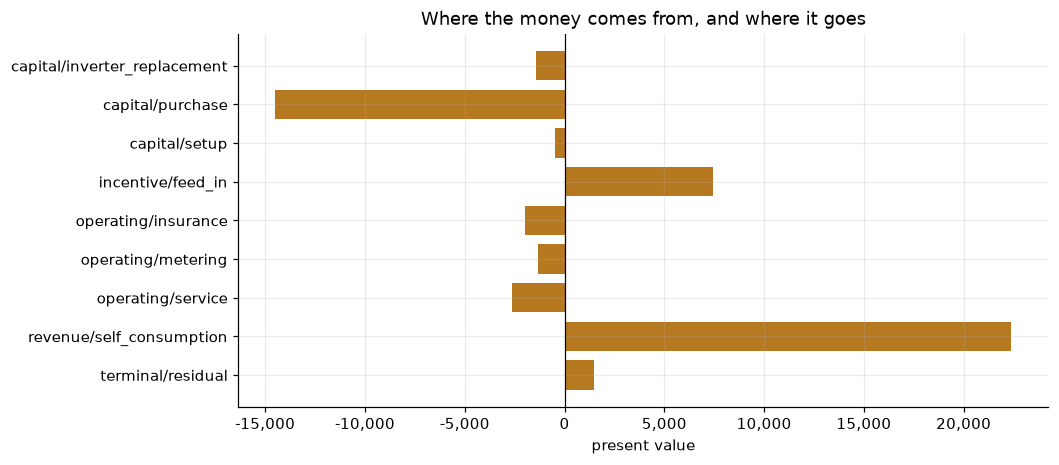

In [3]:
parts = breakdown_frame(result)
display(parts)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
breakdown_chart(result, ax=ax)
ax.set_title("Where the money comes from, and where it goes")
plt.show()

## A year has a shape

A December kilowatt-hour is scarce and an August one is not.  On a monthly grid
that matters, which is why the timeline carries a calendar anchor: the yield is
placed in real months, not spread flat across them.

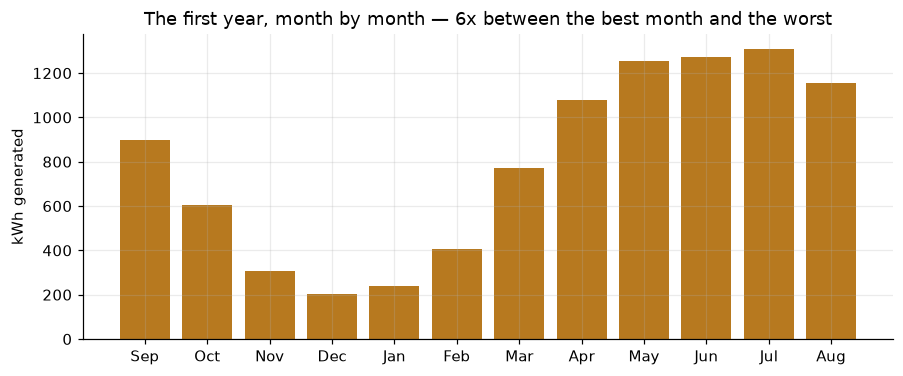

year one 9,500 kWh, year twenty-five 8,423 kWh after degradation


In [4]:
made = supply.per_period(GENERATED, timeline)
first_year = pd.Series(
    made[1:13], index=[timeline.date_of(t - 1).strftime("%b") for t in range(1, 13)]
)

fig, ax = plt.subplots(figsize=(9.5, 3.6))
ax.bar(first_year.index, first_year.to_numpy(), color=SUN)
ax.set_ylabel("kWh generated")
ax.set_title(
    f"The first year, month by month — {first_year.max() / first_year.min():.0f}x "
    f"between the best month and the worst"
)
plt.show()

print(f"year one {made[1:13].sum():,.0f} kWh, year twenty-five {made[-12:].sum():,.0f} kWh "
      f"after degradation")

## The two revenue streams pull apart

This is the part a flat model gets wrong.  The avoided retail price **rises**
with the electricity price.  The feed-in tariff is fixed in nominal terms for
twenty years, then stops.  Twenty-five years is long enough for the gap between
them to become the dominant fact about the investment.

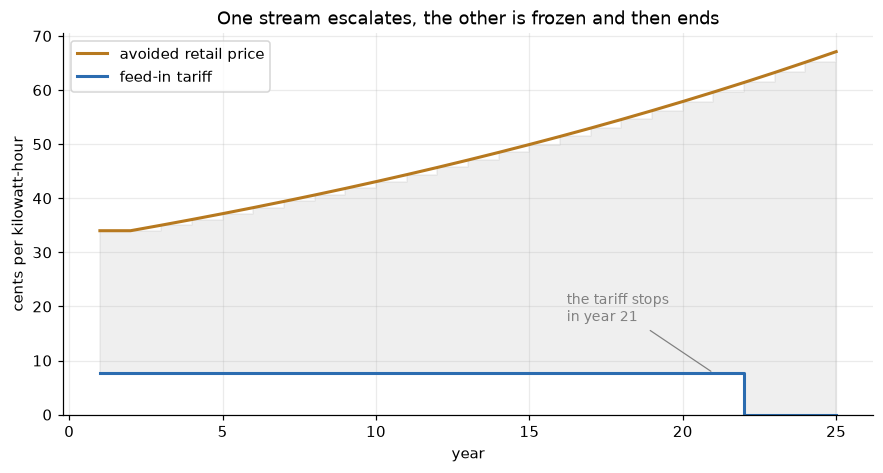

In [5]:
years = np.arange(1, 26)
retail = owner.retail_price.per_kwh(timeline)[::12][:25]
tariff = float(blended_rate(EEG_2026_AUGUST.surplus, 10.0))
paid = np.where(years <= 21, tariff, 0.0)  # 20 years plus the commissioning year

fig, ax = plt.subplots()
ax.plot(years, retail * 100, color=SUN, linewidth=2, label="avoided retail price")
ax.step(years, paid * 100, where="post", color=GRID, linewidth=2, label="feed-in tariff")
ax.fill_between(years, retail * 100, paid * 100, step="post", color="grey", alpha=0.12)
ax.annotate(
    "the tariff stops\nin year 21",
    xy=(21, tariff * 100),
    xytext=(-96, 34),
    textcoords="offset points",
    fontsize=9,
    color="grey",
    arrowprops={"arrowstyle": "-", "color": "grey", "linewidth": 0.8},
)
ax.set_ylim(bottom=0)
ax.set_xlabel("year")
ax.set_ylabel("cents per kilowatt-hour")
ax.set_title("One stream escalates, the other is frozen and then ends")
ax.legend(loc="upper left")
plt.show()

## The only question that matters

Nobody knows a household's hour-by-hour load, so this model does not pretend to.
It takes the self-consumption share as a stated assumption — and then asks what
that assumption has to be worth for the roof to pay.

Pairing the system against doing nothing turns that into a switch point.

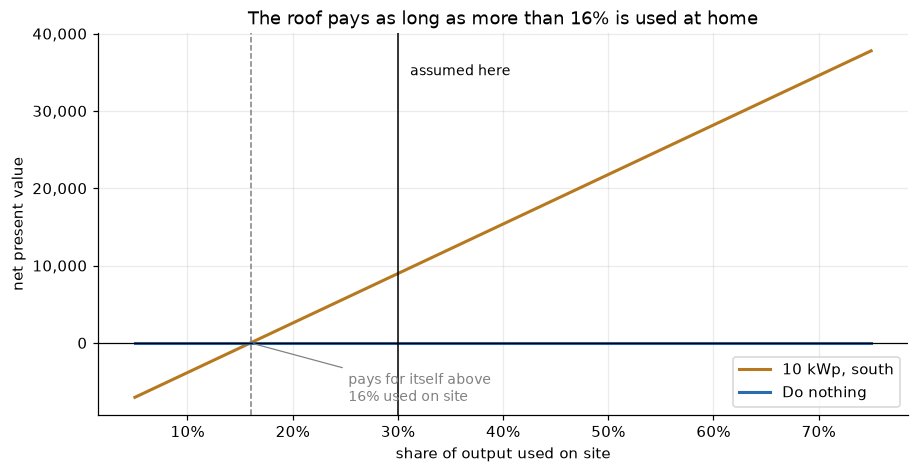

Do nothing leads while self-consumption is below 0.16, 10 kWp, south above it


In [6]:
marked_plan, marked_owner, marked_supply, grid = roof(marked=True)
case = Case(
    alternatives=(marked_plan, Alternative("Do nothing")),
    timeline=grid,
    party=marked_owner,
    usage=marked_supply,
)

break_even = switch_point(
    case, "self-consumption", better="10 kWp, south", worse="Do nothing", bracket=(0.0, 1.0)
)
swept = one_way(case, "self-consumption", np.linspace(0.05, 0.75, 71))

fig, ax = plt.subplots()
sweep_chart(swept, switch=break_even, ax=ax)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.annotate(
    f"pays for itself above\n{break_even.value:.0%} used on site",
    xy=(break_even.value, 0.0),
    xytext=(64, -38),
    textcoords="offset points",
    fontsize=9,
    color="grey",
    arrowprops={"arrowstyle": "-", "color": "grey", "linewidth": 0.8},
)
ax.axvline(0.30, color="black", linewidth=1)
ax.annotate("assumed here", xy=(0.30, swept.npv.max()), xytext=(8, -16),
            textcoords="offset points", fontsize=9)
ax.xaxis.set_major_formatter(lambda value, _: f"{value:.0%}")
ax.set_xlabel("share of output used on site")
ax.set_title(f"The roof pays as long as more than {break_even.value:.0%} is used at home")
plt.show()

print(break_even)

A break-even of roughly one kilowatt-hour in six is a low bar.  A household that
is out all day still clears it, which is a far more robust conclusion than any
single simulated load profile could have given — and it is honest about the fact
that the exact share was never known.

## When it pays back

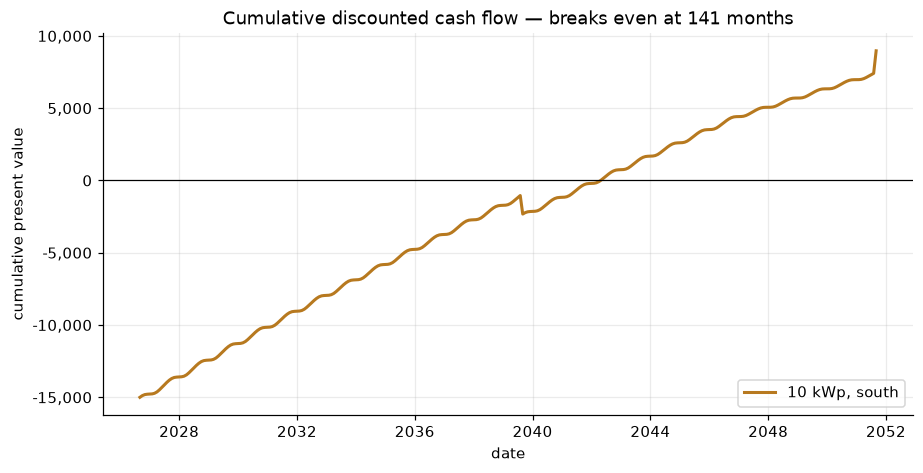

In [7]:
fig, ax = plt.subplots()
cumulative_chart(result, ax=ax)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.set_title(f"Cumulative discounted cash flow — breaks even at {result.payback}")
ax.legend(loc="lower right")
plt.show()

## Being paid nothing when the sun is loudest

Since February 2025 a new system earns no tariff in any quarter-hour when the
spot price is negative — and those quarter-hours are, by construction, exactly
when every roof in the country is producing.  §51a appends the lost time to the
end of the twenty years, so the energy is not forfeited.

It arrives two decades late, though, and that is what discounting does to it.

In [8]:
rows = []
for lost in (0.0, 0.05, 0.10, 0.20):
    docked, who, made, grid = roof(negative=lost)
    priced = appraise(docked, grid, party=who, usage=made)
    parts = {str(k): float(v) for k, v in priced.breakdown().items()}
    rows.append(
        {
            "negative-price share": lost,
            "feed-in": parts.get("incentive/feed_in", 0.0),
            "makeup (§51a)": parts.get("incentive/negative_price_makeup", 0.0),
            "net present value": float(priced.npv),
        }
    )

lost_table = pd.DataFrame(rows).set_index("negative-price share")
display(lost_table)

whole = lost_table.loc[0.00, "feed-in"]
at_ten = lost_table.loc[0.10]
recovered = at_ten["makeup (§51a)"] / (whole - at_ten["feed-in"])
print(f"at a 10% share the tariff loses {whole - at_ten['feed-in']:,.2f} of present value "
      f"and the extension returns {at_ten['makeup (§51a)']:,.2f} — {recovered:.0%} of it.")

,feed-in,makeup (§51a),net present value
negative-price share,,,
0.00,"7,433.33",0.00,"8,968.67"
0.05,"7,061.67",270.48,"8,867.48"
0.10,"6,690.00",540.96,"8,766.30"
0.20,"5,946.67","1,081.91","8,563.92"


at a 10% share the tariff loses 743.33 of present value and the extension returns 540.96 — 73% of it.


## Commissioning in 2026 against 2027

The fixed tariff degresses one per cent every six months, which is a detail.  The
government's draft amendment replacing it from January 2027 with 5.20 ct/kWh for
thirty-six months, and direct marketing thereafter, is not a detail.

It is a published draft and not law, so the model will not use it unless it is
handed over deliberately.

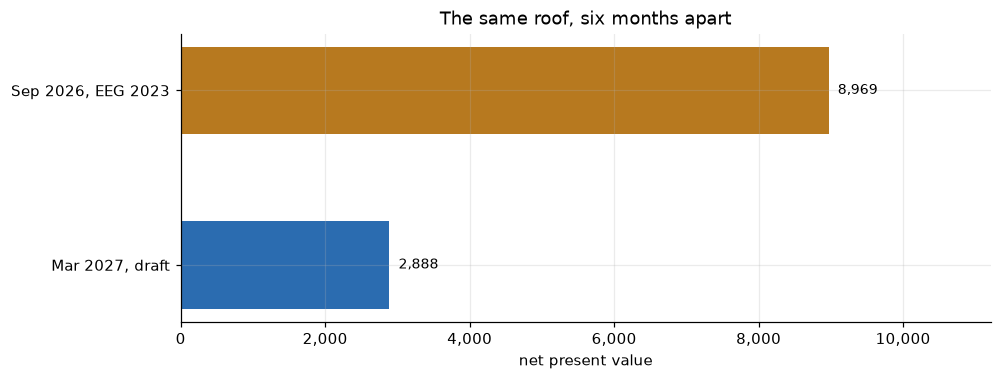

waiting until March 2027 costs 68% of the value, if the draft becomes law.


In [9]:
regimes = {
    "Sep 2026, EEG 2023": (LIVE, (EEG_2026_AUGUST,)),
    "Mar 2027, draft": (date(2027, 3, 1), (EEG_2026_AUGUST, EEG_2027_DRAFT)),
}
outcome = {}
for name, (when, table) in regimes.items():
    built, who, made, grid = roof(commissioned=when, regimes=table)
    outcome[name] = float(appraise(built, grid, party=who, usage=made).npv)

fig, ax = plt.subplots(figsize=(9.5, 3.4))
bars = ax.barh(list(outcome), list(outcome.values()), color=[SUN, GRID], height=0.5)
ax.bar_label(bars, fmt="%,.0f" if False else (lambda v: f"{v:,.0f}"), padding=6, fontsize=9)
ax.xaxis.set_major_formatter(MONEY)
ax.set_xlim(0, max(outcome.values()) * 1.25)
ax.set_xlabel("net present value")
ax.set_title("The same roof, six months apart")
ax.invert_yaxis()
plt.show()

drop = 1 - outcome["Mar 2027, draft"] / outcome["Sep 2026, EEG 2023"]
print(f"waiting until March 2027 costs {drop:.0%} of the value, if the draft becomes law.")

## What the answer turns on

,low,high,swing
parameter,,,
self-consumption,"5,767.29","14,651.95","8,884.66"
retail price,"6,436.40","11,500.95","5,064.55"
yield,"6,956.82","10,980.53","4,023.72"
installed price,"10,004.78","7,932.56","2,072.22"


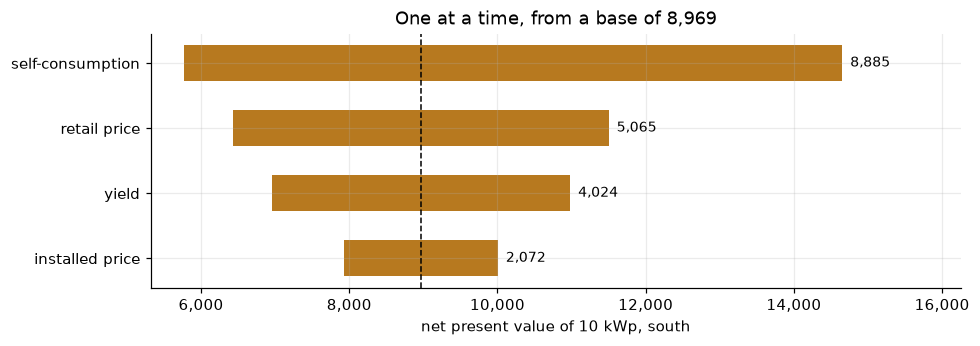

In [10]:
swings = tornado(case, on="10 kWp, south")
display(tornado_frame(swings))

fig, ax = plt.subplots(figsize=(9.5, 3.0))
tornado_chart(swings, ax=ax)
ax.set_title(f"One at a time, from a base of {swings.base:,.0f}")
plt.show()

### The parameter that is missing from that chart

Electricity price escalation is almost certainly the largest uncertainty here,
and it is **not** in the tornado: a `Timeline` stores its escalation rates as
plain floats, so `uncertain()` cannot mark one.  Sweeping it means rebuilding the
case, which is what this does.

The slope is the point.  Between one and five per cent a year the answer more
than triples — a wider swing than anything the tornado found, and the one number
here that nobody can honestly pin down.

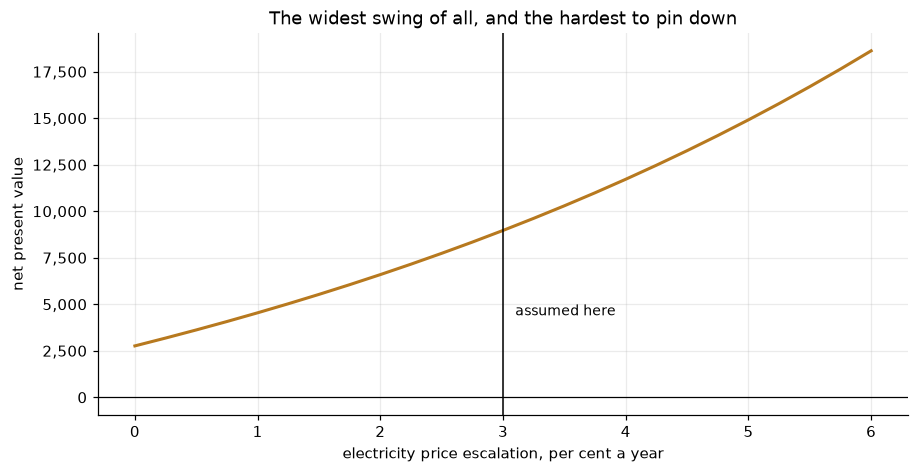

at 1% a year: 4,542
at 5% a year: 14,912


In [11]:
rates = np.linspace(0.0, 0.06, 25)
def value_at(rate):
    built, who, made, grid = roof(escalation=rate)
    return float(appraise(built, grid, party=who, usage=made).npv)


by_rate = np.array([value_at(rate) for rate in rates])

fig, ax = plt.subplots()
ax.plot(rates * 100, by_rate, color=SUN, linewidth=2)
ax.axvline(3.0, color="black", linewidth=1)
ax.annotate("assumed here", xy=(3.0, by_rate.min()), xytext=(8, 20),
            textcoords="offset points", fontsize=9)
ax.axhline(0.0, color="black", linewidth=0.8)
ax.yaxis.set_major_formatter(MONEY)
ax.set_xlabel("electricity price escalation, per cent a year")
ax.set_ylabel("net present value")
ax.set_title("The widest swing of all, and the hardest to pin down")
plt.show()

print(f"at 1% a year: {np.interp(0.01, rates, by_rate):,.0f}")
print(f"at 5% a year: {np.interp(0.05, rates, by_rate):,.0f}")

## All of it at once

Four of the five unknowns drawn together, twenty thousand times.  The question is
not what the roof is worth — it is how often it is worth anything at all.

resolved in one batched pass: True


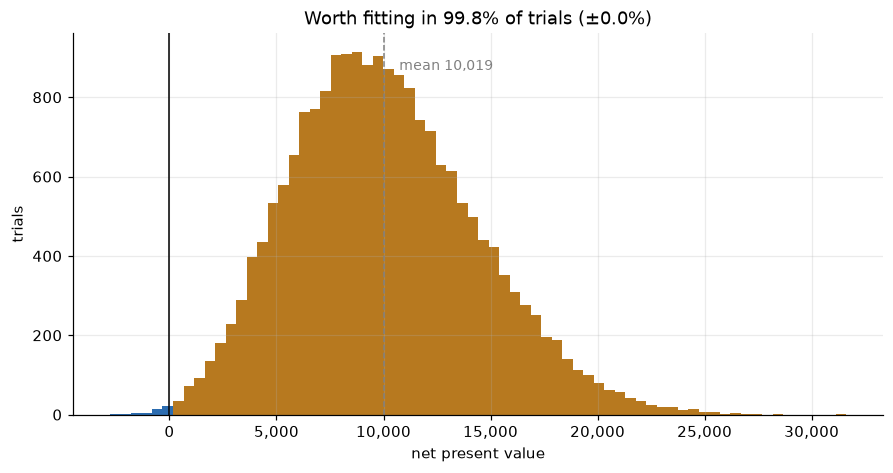

,net present value
percentile,
5.00,"3,474.22"
25.00,"6,917.98"
50.00,"9,695.32"
75.00,"12,783.23"
95.00,"17,672.28"


In [12]:
trials = simulate(case, n=20_000, seed=20261006)
print(f"resolved in one batched pass: {trials.batched}")

fig, ax = plt.subplots()
values = trials.values("10 kWp, south")
counts, edges = np.histogram(values, bins=70)
centres = (edges[:-1] + edges[1:]) / 2
ax.bar(centres, counts, width=np.diff(edges),
       color=[SUN if c > 0 else GRID for c in centres])
ax.axvline(0.0, color="black", linewidth=1)
ax.axvline(values.mean(), color="grey", linestyle="--", linewidth=1)
ax.annotate(f"mean {values.mean():,.0f}", xy=(values.mean(), counts.max()),
            xytext=(10, -12), textcoords="offset points", fontsize=9, color="grey")
ax.xaxis.set_major_formatter(MONEY)
ax.set_xlabel("net present value")
ax.set_ylabel("trials")
ax.set_title(
    f"Worth fitting in {trials.probability('10 kWp, south', 'Do nothing'):.1%} of trials "
    f"(±{trials.standard_error('10 kWp, south', 'Do nothing'):.1%})"
)
plt.show()

display(pd.DataFrame({
    "net present value": trials.npv_percentiles("10 kWp, south", (5.0, 25.0, 50.0, 75.0, 95.0))
}).rename_axis("percentile"))

## What this does not price

Everything above rests on a stated yield and a stated share.  Neither was
simulated, and the model says so rather than implying a precision it has not got.

In [13]:
for note in result.constraints:
    print(f"- {note}\n")

- Self-consumption is valued at the working price alone.  The standing charge is owed whatever the roof does, so it is not avoided.

- The roof is assumed to carry the array for the whole horizon; stripping and refitting it for a re-roof is not priced.

- This implies about 2,685 kWh a year used on site.  Check that against a bill before trusting the result.

- No storage is fitted, so everything generated outside the hours it is used is exported.

- The tariff is fixed in money of the day for the whole term, so it buys less every year.  The retail price it is compared against does not.

- These figures assume EStG §3 Nr. 72 applies: the system is at most 30 kWp on a dwelling, and the operator stays under the 100 kWp cap across everything they own.  Above either limit the feed-in revenue is taxable and this appraisal understates the cost.

